<div align="center">

## K-means `scikit-learn`

</div>


<div align="center"> 
<a href="https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html"><img src="http://scikit-learn.org/stable/_static/scikit-learn-logo-small.png" style="max-width: 180px; display: inline" alt="Scikit-Learn"/></a>
</div>


<div align="center"> 

## [S. Mussard](https://sites.google.com/view/cv-stphane-mussard/accueil "Homepage")

</div>


In [1]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
import pandas as pd
import numpy as np
from numpy import dot
from numpy.linalg import norm
from sklearn.base import clone
from sklearn.utils import shuffle
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from collections import Counter
from num2words import num2words
import nltk





In [2]:
# Install
#pip install nltk

In [3]:
base = pd.read_excel('bank.xlsx')
base
#T

,Customer Satisfaction,Real Estate Savings,Number of Real Estate Credits,Number of Withdrawals,Risk of Default,Product Type,Number of Advices,Number of BOT Advices,Number of Transfers,Gender,Home Savings Plan,Age,Education,Income
0,"A very high-quality after-sales service, perfe...",yes,0,13,yes,C,0,1,0,M,yes,31,5.0,393
1,"Unique products offered at affordable prices, ...",yes,0,11,yes,C,4,0,0,F,yes,34,2.0,347
2,Increase in bank card fees but not excellent q...,yes,0,15,yes,C,0,1,0,F,yes,30,5.0,1172
3,Increasing prices is conceivable but with cons...,yes,0,11,yes,C,1,0,0,F,yes,32,4.0,2392
4,"A very high-quality customer relationship, wit...",yes,1,12,yes,C,0,2,13,F,yes,28,5.0,2777
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,"The content of banking services is enriched, a...",yes,1,13,no,B,1,0,31,M,yes,31,6.0,5007
98,"Frankly, their website is really well designed...",yes,0,14,no,C,1,0,26,F,yes,45,2.0,1397
99,"A very high-quality after-sales service, perfe...",yes,2,14,no,B,1,0,24,F,yes,31,0.2,4173
100,"Unique products offered at affordable prices, ...",yes,1,15,no,C,0,4,17,M,yes,58,0.0,4241


In [4]:
# Supression des lignes vides :

base_f = base[['Customer Satisfaction']]
base_f = base_f.copy()
base_f.dropna(how='any', inplace=True)
#base.dtypes
base_f

,Customer Satisfaction
0,"A very high-quality after-sales service, perfe..."
1,"Unique products offered at affordable prices, ..."
2,Increase in bank card fees but not excellent q...
3,Increasing prices is conceivable but with cons...
4,"A very high-quality customer relationship, wit..."
...,...
97,"The content of banking services is enriched, a..."
98,"Frankly, their website is really well designed..."
99,"A very high-quality after-sales service, perfe..."
100,"Unique products offered at affordable prices, ..."


In [5]:
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Customer Satisfaction          102 non-null    object 
 1   Real Estate Savings            102 non-null    object 
 2   Number of Real Estate Credits  102 non-null    int64  
 3   Number of Withdrawals          102 non-null    int64  
 4   Risk of Default                102 non-null    object 
 5   Product Type                   102 non-null    object 
 6   Number of Advices              102 non-null    int64  
 7   Number of BOT Advices          102 non-null    int64  
 8   Number of Transfers            102 non-null    int64  
 9   Gender                         102 non-null    object 
 10  Home Savings Plan              102 non-null    object 
 11  Age                            102 non-null    int64  
 12  Education                      102 non-null    flo

In [6]:
# corpus
corpus = []
for comments in base_f['Customer Satisfaction'] :
    corpus.append(comments)
corpus

['A very high-quality after-sales service, perfectly meeting expectations.',
 'Unique products offered at affordable prices, it’s an excellent offer!',
 'Increase in bank card fees but not excellent quality of financial products!',
 'Increasing prices is conceivable but with consistently quality service, good!',
 'A very high-quality customer relationship, with personalized and efficient support!',
 'Perfect for my bank card and savings accounts!',
 'Very satisfied with my new bank card and my online savings account, it’s great!',
 'Ideal for young people, with good products and impeccable customer service.',
 'Excellent customer relationship, always attentive! It’s truly a real bank.',
 'The content of banking services is enriched, and the bank card subscription remains competitive.',
 'Frankly, their website is really well designed and practical, even for those new to trading!',
 'A very high-quality after-sales service, perfectly meeting expectations.',
 'Unique products offered at 

In [7]:
# Vectorisation

#vectorizer = TfidfVectorizer()

# Prendre ddes 1 grammes au 3 grammes
vectorizer = TfidfVectorizer(ngram_range = (3,3), max_df = 0.99, min_df = 0.01, max_features=100, norm = 'l2', binary = False) 
vectors = vectorizer.fit_transform(corpus)
feature_names = vectorizer.get_feature_names_out()
tf_idf = pd.DataFrame(vectors.toarray(), columns=feature_names)
tf_idf.head(4)

,account it great,affordable prices it,after sales service,always attentive it,an excellent offer,and efficient support,and impeccable customer,and my online,and practical even,and savings accounts,...,unique products offered,very high quality,very satisfied with,website is really,well designed and,with consistently quality,with good products,with my new,with personalized and,young people with
0,0.0,0.000000,0.387355,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.315811,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
1,0.0,0.353553,0.000000,0.0,0.353553,0.0,0.0,0.0,0.0,0.0,...,0.353553,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
2,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
3,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.353553,0.0,0.0,0.0,0.0


In [8]:
# Kmeans

from sklearn.cluster import KMeans
X = np.asarray(tf_idf)
kmeans = KMeans(n_clusters=2, metric = 'gini', algorith = 'lloyd', random_state=0).fit(X)
kmeans.labels_

TypeError: KMeans.__init__() got an unexpected keyword argument 'metric'

In [18]:
# Insertion des labels dans X : attention à exécuter q'une fois sinon la colonne va apparaitre plusieurs fois dans le dataframe

df.insert(0, 'label', kmeans.labels_)
df

,label,activités,ambiance,autres,beaucoup,bien,bienveillance,bon,bonne,cabinet,...,très,télétravail,vie,week,écoute,équilibre,équipe,évènements,événements,être
0,0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.242384,...,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0
1,0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0
2,0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.000000,0.516063,0.0,0.000000,0.0,0.000000,0.000000,0.0
3,1,0.0,0.293576,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.663775,0.000000,0.0,0.386191,0.0,0.000000,0.000000,0.0
4,1,0.0,0.000000,0.0,0.288826,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.262210,0.000000,0.0,0.305113,0.0,0.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
956,1,0.0,0.238835,0.0,0.000000,0.0,0.0,0.0,0.274299,0.000000,...,0.0,0.0,0.540006,0.000000,0.0,0.314182,0.0,0.000000,0.000000,0.0
957,1,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.329042,0.000000,0.0,0.000000,0.0,0.368109,0.000000,0.0
958,0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.000000,0.429583,0.0,0.000000,0.0,0.000000,0.348294,0.0
959,0,0.0,0.365688,0.0,0.000000,0.0,0.0,0.0,0.419988,0.000000,...,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.399855,0.0


In [19]:
df.describe()

# mean ? Explication ?

,label,activités,ambiance,autres,beaucoup,bien,bienveillance,bon,bonne,cabinet,...,très,télétravail,vie,week,écoute,équilibre,équipe,évènements,événements,être
count,961.000000,961.000000,961.000000,961.000000,961.000000,961.000000,961.000000,961.000000,961.000000,961.000000,...,961.000000,961.000000,961.000000,961.000000,961.000000,961.000000,961.000000,961.000000,961.000000,961.000000
mean,0.048907,0.011328,0.039588,0.010857,0.017333,0.016900,0.024687,0.012648,0.025113,0.016550,...,0.036606,0.020508,0.030585,0.014776,0.015470,0.014666,0.022059,0.018249,0.027286,0.017322
std,0.215787,0.068324,0.126061,0.057332,0.080198,0.071639,0.113322,0.067625,0.100071,0.071385,...,0.110554,0.110823,0.123339,0.079799,0.083619,0.075339,0.098983,0.088626,0.107276,0.075796
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,0.760808,1.000000,0.491550,0.696405,0.545749,1.000000,0.670286,0.729262,0.688128,...,1.000000,1.000000,1.000000,0.596466,0.810904,0.728005,0.770719,0.801994,1.000000,0.590538


In [20]:
#Filtrage de la base par label de Kmeans

data_label_0 = df.loc[df['label'] == 0]
data_label_1 = df.loc[df['label'] == 1]

#Supression de la colonne label:

data_label_0 = data_label_0.drop(['label'], axis=1)
data_label_1 = data_label_1.drop(['label'], axis=1)

In [24]:
# Quels sont les termes qui ont une moyenne (TD-IDF) importante :

# Label 1 :
mean_1 = data_label_1.describe()

# On trie les termes du label 1 du plus important au moins important selon la ligne 'mean':
mean_1.sort_values(by = 'mean', axis = 1, ascending=False)


,vie,pro,équilibre,perso,bon,entreprise,bonne,évènements,ambiance,entre,...,soirées,entraide,notre,qualité,qu,possibilité,leur,où,ne,être
count,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,...,47.0,47.0,47.0,47.0,47.0,47.0,47.0,47.0,47.0,47.0
mean,0.497593,0.259237,0.255714,0.228090,0.043909,0.039704,0.038267,0.030758,0.030289,0.029515,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
std,0.227179,0.166969,0.186587,0.201181,0.122028,0.091144,0.094334,0.101972,0.081550,0.088711,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,0.323851,0.082815,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,0.516971,0.319852,0.314182,0.310388,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,0.673625,0.371376,0.393956,0.393717,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,1.000000,0.556075,0.593790,0.596865,0.500602,0.344660,0.351238,0.371459,0.293576,0.396844,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [25]:
mean_0 = data_label_0.describe()
mean_0.sort_values(by = 'mean', axis = 1, ascending=False)

,collaborateurs,management,est,entreprise,travail,ambiance,très,esprit,sont,entre,...,place,ses,où,salariés,je,qu,vie,pro,équilibre,perso
count,914.000000,914.000000,914.000000,914.000000,914.000000,914.000000,914.000000,914.000000,914.000000,914.000000,...,914.000000,914.000000,914.000000,914.000000,914.000000,914.000000,914.000000,914.000000,914.000000,914.000000
mean,0.052946,0.049736,0.046316,0.042153,0.040568,0.040067,0.037090,0.035654,0.033810,0.031255,...,0.010864,0.010376,0.010357,0.010334,0.009336,0.009242,0.006570,0.004111,0.002271,0.002004
std,0.116292,0.125500,0.115973,0.110692,0.120021,0.127944,0.112063,0.126874,0.101415,0.108987,...,0.061230,0.060027,0.057272,0.068061,0.059387,0.055332,0.039882,0.040949,0.032698,0.026655
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,0.649516,1.000000,0.769514,1.000000,0.884830,1.000000,1.000000,1.000000,0.775665,0.897933,...,0.594996,0.601075,0.606570,0.762986,0.704928,0.663373,0.369962,0.746448,0.728005,0.506128


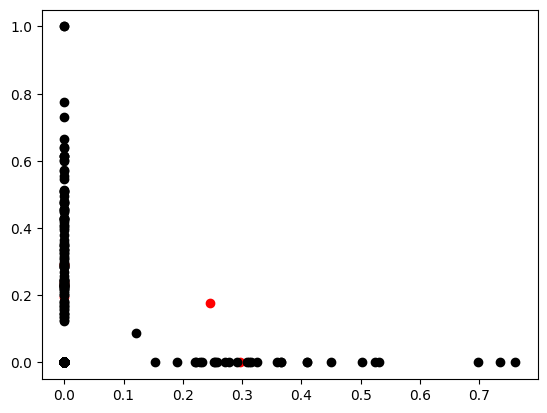

In [26]:
#Plot Kmeans

import matplotlib.pyplot as plt
plt.scatter(data_label_1.iloc[:,0] , data_label_1.iloc[:,1] , color = 'red')
plt.scatter(data_label_0.iloc[:,0] , data_label_0.iloc[:,1] , color = 'black')
plt.show()

In [27]:
# Insertion des labels dans le dataframe de départ

base_f.insert(0, 'label', kmeans.labels_)
base_f

,label,commentaire
0,0,"**** "" des prises de décisions collectives (au..."
1,0,Accompagnement personnalisé - Possibilités d...
2,0,Afterwork de practice - Week-end ski - locau...
3,1,Ambiance chaleureuse et côté familial - Équil...
4,1,"beaucoup de moments de convivialité', - solli..."
...,...,...
956,1,"""Équilibre vie pro/vie perso Bonne ambiance de..."
957,1,"""évènements, suivi de carrière, contribution e..."
958,0,"""Événements bimensuels de présentations des ré..."
959,0,"""Événements réguliers qui permettent de mieux ..."


In [28]:
y = np.asarray(base_f['label'])  # output
y = y.astype(float)
df = df.drop(['label'], axis=1)
df

,activités,ambiance,autres,beaucoup,bien,bienveillance,bon,bonne,cabinet,cdm,...,très,télétravail,vie,week,écoute,équilibre,équipe,évènements,événements,être
0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.242384,0.135255,...,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0
1,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,...,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0
2,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,...,0.0,0.0,0.000000,0.516063,0.0,0.000000,0.0,0.000000,0.000000,0.0
3,0.0,0.293576,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,...,0.0,0.0,0.663775,0.000000,0.0,0.386191,0.0,0.000000,0.000000,0.0
4,0.0,0.000000,0.0,0.288826,0.0,0.0,0.0,0.000000,0.000000,0.000000,...,0.0,0.0,0.262210,0.000000,0.0,0.305113,0.0,0.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
956,0.0,0.238835,0.0,0.000000,0.0,0.0,0.0,0.274299,0.000000,0.000000,...,0.0,0.0,0.540006,0.000000,0.0,0.314182,0.0,0.000000,0.000000,0.0
957,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,...,0.0,0.0,0.329042,0.000000,0.0,0.000000,0.0,0.368109,0.000000,0.0
958,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,...,0.0,0.0,0.000000,0.429583,0.0,0.000000,0.0,0.000000,0.348294,0.0
959,0.0,0.365688,0.0,0.000000,0.0,0.0,0.0,0.419988,0.000000,0.000000,...,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.399855,0.0


In [29]:
#!pip install scikit-learn-intelex
#from sklearnex import patch_sklearn
#patch_sklearn()
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

X = np.asarray(df)
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state = 1)

classifiers = [
    KNeighborsClassifier(2),
    LogisticRegression(penalty="l1", tol=0.01, solver="saga"),
    SVC(kernel="linear", C=0.025),
    SVC(gamma=2, C=1),
    DecisionTreeClassifier(max_depth=5),
    RandomForestClassifier(),
    MLPClassifier(max_iter=1000),
    AdaBoostClassifier(),
    GaussianNB(),
    QuadraticDiscriminantAnalysis(),
    LinearDiscriminantAnalysis()
]

for clf in classifiers:
    clf.fit(X_train, y_train)   
    y_pred = clf.predict(X_test)
    print(clf,':')
    print('Accuracy :', accuracy_score(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    print('')


KNeighborsClassifier(n_neighbors=2) :
Accuracy : 1.0
[[185   0]
 [  0   8]]

LogisticRegression(penalty='l1', solver='saga', tol=0.01) :
Accuracy : 1.0
[[185   0]
 [  0   8]]

SVC(C=0.025, kernel='linear') :
Accuracy : 0.9585492227979274
[[185   0]
 [  8   0]]

SVC(C=1, gamma=2) :
Accuracy : 0.9948186528497409
[[184   1]
 [  0   8]]

DecisionTreeClassifier(max_depth=5) :
Accuracy : 1.0
[[185   0]
 [  0   8]]

RandomForestClassifier() :
Accuracy : 0.9948186528497409
[[184   1]
 [  0   8]]

MLPClassifier(max_iter=1000) :
Accuracy : 0.9896373056994818
[[183   2]
 [  0   8]]

AdaBoostClassifier() :
Accuracy : 1.0
[[185   0]
 [  0   8]]

GaussianNB() :
Accuracy : 0.40414507772020725
[[ 73 112]
 [  3   5]]

QuadraticDiscriminantAnalysis() :
Accuracy : 0.9585492227979274
[[185   0]
 [  8   0]]

LinearDiscriminantAnalysis() :
Accuracy : 0.9844559585492227
[[182   3]
 [  0   8]]



C:\Users\smussa01\AppData\Roaming\Python\Python37\site-packages\sklearn\discriminant_analysis.py:878: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


### Exercices 

# 1) Refaire le même exercice avec 3 groupes : n_clusters=3. De nouveaus thèmes dans le groupe 3 ?

# 1) Prendre des 3 grammes et n_clusters=2, analyser les 2 groupes obtenus. Du changement dans les thèmes ?
vectorizer = TfidfVectorizer(ngram_range = (3,3), max_df = 0.99, min_df = 0.01, max_features=100, norm = 'l2', binary = False) 
